# Street Fighter 6 Ranked Match Data Analyst Project

Hello, this is my personal Street Fighter 6 Ranked Match Data Analyst Project. I'm doing this project to help solidify the skills I learned through IBM's and Google's Online Data Analytics courses. This project is my attempt to practice concepts such as data cleaning, feature engineering, hypothesis testing and logistic regression to incorporate it with my hobby of video games (Street Fighter 6). The goal of this project is to analyze my certain play patterns and utilize the concepts I learned to assess aspects that can be improved upon. Please note that this is my first project so there are still many things that can/could be expanded upon. The write ups and discussions in this project are written under the assumption that the reader does not have any prior Street Fighter 6 knowledge. With that being said this project represents an exciting first step in my journey in becoming a Data Analyst!

In [1]:
###import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
###import datasets
df_match = pd.read_csv('match data.csv')

In [3]:
df_match.head()

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
0,"Feb 17, 2026",1,1,1,1309,1322,Mai,5.0,1.0,0.0,0.0,2,0,L
1,"Feb 17, 2026",1,1,2,1301,1330,Mai,3.0,0.0,1.0,1.0,2,0,L
2,"Feb 17, 2026",1,2,3,1294,1297,Cammy,7.0,1.0,1.0,3.0,2,1,L
3,"Feb 17, 2026",1,2,4,1286,1305,Cammy,3.0,0.0,0.0,3.0,2,1,L
4,"Feb 17, 2026",1,3,5,1278,1300,Ed,2.0,0.0,1.0,2.0,0,2,W


In [4]:
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                485 non-null    object 
 1   Session ID          485 non-null    int64  
 2   Set ID              485 non-null    int64  
 3   Match ID            485 non-null    int64  
 4   Current MR          485 non-null    int64  
 5   Opponent Rank (MR)  485 non-null    int64  
 6   Opponent Character  485 non-null    object 
 7   Jump ins            385 non-null    float64
 8   AA success          385 non-null    float64
 9   Combo Drops         385 non-null    float64
 10  Burnouts            385 non-null    float64
 11  Rounds Lost         485 non-null    int64  
 12  Rounds Won          485 non-null    int64  
 13  Result              485 non-null    object 
dtypes: float64(4), int64(7), object(3)
memory usage: 53.2+ KB


# Data Dictionary

Here is a data dictionary to help give insight on what the data represents. 

Throughout the whole project I played only one Character (Ryu)
1. Each row represents one match, a match result is decided by winning/losing 2 rounds.
2. **Session ID**: The ID number for each Session. A Session is defined an arbitrary amount of matches played. Sessions are differientiated if a long amount of time has passed between playing.
3. **Date**: The date in which the match was played.
4. **Set ID**: The ID number for every Set. A Set consists of any number of 1 to 3 matches. Set ID resets back to 1 at the start of every new session.
5. **Match ID**: The ID number for every Match. Each row is a match, the ID number resets back 1 for every new session.
6. **Current MR**: My MR at the start of the match. For all intents and purposes, MR can be synonymous with ELO a competitive rating representing skill.
7. **Opponent Rank (MR)**: Oppnent's MR at the start of the match
8. **Opponent Character**: The character the Opponent used in the match
9. **Jump ins**: Count of how many times the opponent jumped in towards me in a match. A jump in is counted as an opponent jumping towards me and landing in front either using an attack or technique. (Cross ups and jump overs are not counted for this analysis)
10. **AA success**: Count of AA successes in the match. A successful AA (Anti-Air) is counted when I execute a certain technique (in this case a dragon punch) to stop an opponent from jumping in on me.
11. **Combo Drops**: Count of combos dropped during the match. A combo drop is counted when I am attempting to press a certain sequence of buttons but I input it correctly or with incorrect timing and the combo does not execute.
12. **Burnouts**: Count of burnouts during a match. A burnout occurs when a certain resource called Drive is fully expended.
13. **Rounds Lost**: Number of Rounds lost in a match.
14. **Rounds Won**: Number of Rounds won in a match.
15. **Result**: Match result, W depicting won, L depicting loss.

In [5]:
df_match.describe()

,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won
count,485.000000,485.000000,485.000000,485.000000,485.000000,385.000000,385.000000,385.000000,385.000000,485.000000,485.000000
mean,5.435052,14.791753,34.692784,1203.350515,1211.445361,2.228571,0.667532,0.514286,1.184416,1.230928,1.216495
std,2.501737,11.036376,26.135819,74.376894,97.282283,1.748426,0.897688,0.665699,0.938064,0.852968,0.850702
min,1.000000,1.000000,1.000000,1030.000000,115.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,6.000000,14.000000,1149.000000,1163.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,12.000000,28.000000,1222.000000,1221.000000,2.000000,0.000000,0.000000,1.000000,2.000000,1.000000
75%,7.000000,23.000000,52.000000,1257.000000,1271.000000,3.000000,1.000000,1.000000,2.000000,2.000000,2.000000
max,10.000000,42.000000,100.000000,1332.000000,1473.000000,11.000000,5.000000,3.000000,4.000000,2.000000,2.000000


In [6]:
###from inspecting the describe output it can be seen that there is an input error in Opponent Rank
###115 MR is way too low to be a realistic value, this will be fixed during the data cleaning phase

In [7]:
df_match.dtypes

Date                   object
Session ID              int64
Set ID                  int64
Match ID                int64
Current MR              int64
Opponent Rank (MR)      int64
Opponent Character     object
Jump ins              float64
AA success            float64
Combo Drops           float64
Burnouts              float64
Rounds Lost             int64
Rounds Won              int64
Result                 object
dtype: object

In [8]:
df_match.isnull().sum()

Date                    0
Session ID              0
Set ID                  0
Match ID                0
Current MR              0
Opponent Rank (MR)      0
Opponent Character      0
Jump ins              100
AA success            100
Combo Drops           100
Burnouts              100
Rounds Lost             0
Rounds Won              0
Result                  0
dtype: int64

In [9]:
###the 100 NaN rows are a result of matches that weren't recorded due to the game not saving the replays
###therefore in-match metrics for those games couldn't be recorded

## Data Cleaning

In [10]:
###inspecting MR outlier
df_match.loc[[df_match['Opponent Rank (MR)'].idxmin()]]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
401,"Apr 1, 2026",8,5,11,1127,115,E. Honda,3.0,1.0,0.0,1.0,2,0,L


In [11]:
###cleaning min Opponent MR outlier index 401
df_match.loc[df_match['Opponent Rank (MR)'].idxmin(), 'Opponent Rank (MR)'] = 1154

###checking correction
df_match.loc[[401]]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
401,"Apr 1, 2026",8,5,11,1127,1154,E. Honda,3.0,1.0,0.0,1.0,2,0,L


In [12]:
###filtering for another outliers
df_match[(df_match['Opponent Rank (MR)'] < 1000)]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
429,"Apr 1, 2026",8,17,39,1044,985,Ryu,3.0,1.0,0.0,1.0,1,2,W
430,"Apr 1, 2026",8,17,40,1051,978,Ryu,0.0,0.0,1.0,0.0,0,2,W
439,"Apr 1, 2026",9,5,9,1056,997,Ryu,4.0,2.0,0.0,1.0,0,2,W
440,"Apr 1, 2026",9,5,10,1062,971,Ryu,2.0,2.0,0.0,2.0,0,2,W
445,"Apr 1, 2026",9,8,15,1070,971,Juri,2.0,1.0,0.0,1.0,2,2,W
446,"Apr 1, 2026",9,8,16,1076,965,Juri,5.0,2.0,0.0,1.0,2,1,L
447,"Apr 1, 2026",9,8,17,1066,975,Juri,4.0,2.0,0.0,1.0,0,2,W


In [13]:
###filtering for contradictory round entries
contradictions = df_match[
    ###total rounds must be 2 or 3
    ~(df_match['Rounds Won'] + df_match['Rounds Lost']).isin([2, 3]) |
    ###winners must have exactly 2 rounds won
    ((df_match['Result'] == 'W') & (df_match['Rounds Won'] != 2)) |
    ###losers must have exactly 2 rounds lost
    ((df_match['Result'] == 'L') & (df_match['Rounds Lost'] != 2))
]
contradictions

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
215,"Mar 21, 2026",6,2,6,1220,1254,Kimberly,2.0,0.0,1.0,2.0,0,0,L
396,"Apr 1, 2026",8,3,6,1135,1150,Ryu,3.0,1.0,1.0,2.0,0,1,L
445,"Apr 1, 2026",9,8,15,1070,971,Juri,2.0,1.0,0.0,1.0,2,2,W


In [14]:
###imputing correct values
df_match.loc[[215,396], 'Rounds Lost'] = 2
df_match.loc[445,'Rounds Lost'] = 0
df_match.iloc[[215,396,445]]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
215,"Mar 21, 2026",6,2,6,1220,1254,Kimberly,2.0,0.0,1.0,2.0,2,0,L
396,"Apr 1, 2026",8,3,6,1135,1150,Ryu,3.0,1.0,1.0,2.0,2,1,L
445,"Apr 1, 2026",9,8,15,1070,971,Juri,2.0,1.0,0.0,1.0,0,2,W


In [15]:
###The number of Anti Airs cannot be greater than the amount of jump ins
aa_jumps = df_match[(df_match['Jump ins'] < df_match['AA success'])]
aa_jumps

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
457,"Apr 1, 2026",10,4,10,1063,1045,Lily,0.0,1.0,0.0,2.0,0,2,W


In [16]:
###correcting the row
df_match.loc[457,['Jump ins','AA success']] = [1,0]
df_match.loc[[457]]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
457,"Apr 1, 2026",10,4,10,1063,1045,Lily,1.0,0.0,0.0,2.0,0,2,W


In [17]:
###filtering for any Match ID inputting errors
###Matches from each sessions should be unique
match_count = df_match.groupby(['Session ID', 'Match ID']).size().reset_index(name = 'count')
match_count.head()

,Session ID,Match ID,count
0,1,1,1
1,1,2,1
2,1,3,1
3,1,4,1
4,1,5,1


In [18]:
match_count[match_count['count'] !=1]

,Session ID,Match ID,count


In [19]:
###filtering for any Set ID inputting errors
set_count = df_match.groupby(['Session ID', 'Set ID']).size().reset_index(name = 'count')
set_count.head()

,Session ID,Set ID,count
0,1,1,2
1,1,2,2
2,1,3,3
3,1,4,2
4,1,5,2


In [20]:
###sets can only consist of 1,2,3 matches
set_count[~set_count['count'].isin([1,2,3])]

,Session ID,Set ID,count


In [21]:
###ensuring all the character names are correctly spelled
valid_characters = ['Alex', 'C.Viper', 'Sagat', 
                    'Elena', 'Mai', 'Terry',
                    'M.Bison', 'Akuma', 'Ed', 
                    'A.K.I','Rashid', 'Cammy',
                    'Lily','Zangief','JP',
                    'Marisa','Manon','Dee Jay',
                    'E. Honda', 'Dhalsim','Blanka',
                    'Ken','Juri','Kimberly','Guile',
                    'Chun-Li','Jamie','Luke','Ryu']

misspelled = df_match[~df_match['Opponent Character'].isin(valid_characters)]
misspelled

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result
6,"Feb 17, 2026",1,3,7,1279,1299,Ed,2.0,1.0,0.0,0.0,2,1,L
21,"Feb 17, 2026",1,11,22,1230,1207,Marissa,0.0,0.0,0.0,1.0,2,0,L
22,"Feb 17, 2026",1,11,23,1221,1216,Marissa,1.0,0.0,1.0,1.0,2,0,L
23,"Feb 17, 2026",1,12,24,1213,1226,Marissa,1.0,0.0,0.0,1.0,0,2,W
24,"Feb 17, 2026",1,12,25,1221,1218,Marissa,0.0,0.0,0.0,1.0,2,1,L
25,"Feb 17, 2026",1,12,26,1213,1226,Marissa,1.0,0.0,1.0,1.0,0,2,W
81,"Mar 4, 2026",3,3,6,1238,1217,Chun Li,0.0,0.0,0.0,0.0,2,0,L
82,"Mar 4, 2026",3,3,7,1230,1225,Chun Li,3.0,0.0,1.0,3.0,1,2,W
83,"Mar 4, 2026",3,3,8,1238,1217,Chun Li,2.0,1.0,1.0,2.0,1,2,W
339,"Mar 31, 2026",7,14,30,1161,1162,Chun li,2.0,0.0,0.0,2.0,0,2,W


In [22]:
###correcting spelling errors
df_match.loc[6, 'Opponent Character'] = 'Ed'
df_match.loc[21:25, 'Opponent Character'] = 'Marisa'
df_match.loc[np.r_[81:84,339:342,351:354], 'Opponent Character'] = 'Chun-Li'

In [23]:
###checking corrections
df_match[~df_match['Opponent Character'].isin(valid_characters)]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result


In [24]:
###ensuring Result column is clean
valid_result = ['W','L']

invalid_res = df_match[~df_match['Result'].isin(valid_result)]
invalid_res

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result


## EDA

In [25]:
###encoding Result column
df_match['result num'] = df_match['Result'].map({'W': 1,
                                                 'L': 0})
df_match.head()

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num
0,"Feb 17, 2026",1,1,1,1309,1322,Mai,5.0,1.0,0.0,0.0,2,0,L,0
1,"Feb 17, 2026",1,1,2,1301,1330,Mai,3.0,0.0,1.0,1.0,2,0,L,0
2,"Feb 17, 2026",1,2,3,1294,1297,Cammy,7.0,1.0,1.0,3.0,2,1,L,0
3,"Feb 17, 2026",1,2,4,1286,1305,Cammy,3.0,0.0,0.0,3.0,2,1,L,0
4,"Feb 17, 2026",1,3,5,1278,1300,Ed,2.0,0.0,1.0,2.0,0,2,W,1


In [26]:
###expressing AA success as a %
###filter out games where opponent didn't jump in (0 jump ins over 0 AA success is  invalid)
df_match['AA valid'] = (df_match['Jump ins'] > 0).astype(int) 
df_match['AA rate'] = df_match['AA success']/df_match['Jump ins']
jump_in = df_match[df_match['AA valid'] == 1]
jump_in.head()

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate
0,"Feb 17, 2026",1,1,1,1309,1322,Mai,5.0,1.0,0.0,0.0,2,0,L,0,1,0.200000
1,"Feb 17, 2026",1,1,2,1301,1330,Mai,3.0,0.0,1.0,1.0,2,0,L,0,1,0.000000
2,"Feb 17, 2026",1,2,3,1294,1297,Cammy,7.0,1.0,1.0,3.0,2,1,L,0,1,0.142857
3,"Feb 17, 2026",1,2,4,1286,1305,Cammy,3.0,0.0,0.0,3.0,2,1,L,0,1,0.000000
4,"Feb 17, 2026",1,3,5,1278,1300,Ed,2.0,0.0,1.0,2.0,0,2,W,1,1,0.000000


In [27]:
###MR metrics
###MR change between Sessions and Sets

###certain large mr discrepencies between different sessions are due to free playing (playing for the sake of playing and not recording data)
###therefore nullifying certain session boundaries to prevent the large discrepencies being represented in MR charges

df_match['MR_After'] = df_match['Current MR'].shift(-1)
last_match_per_session = df_match.groupby('Session ID').tail(1).index

session_boarders = sorted(set(last_match_per_session) | set(last_match_per_session + 1))
session_boarders = [i for i in session_boarders if i in df_match.index]

df_match.loc[session_boarders][['Session ID', 'Match ID', 'Current MR', 'MR_After']]

,Session ID,Match ID,Current MR,MR_After
31,1,32,1230,1238.0
32,2,1,1238,1247.0
75,2,44,1205,1212.0
76,3,1,1212,1220.0
109,3,34,1300,1308.0
110,4,1,1308,1300.0
205,4,96,1291,1300.0
206,5,1,1300,1293.0
209,5,4,1294,1230.0
210,6,1,1230,1237.0


In [28]:
###rows 209,309,390,484 have After MR outlier values input them to be normal mr gains/losses based on W or L
df_match.loc[[209,309,390,484], 'MR_After'] = [1302,1220,1151,1163]

In [29]:
df_match.loc[[209,309,390,484]]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate,MR_After
209,"Mar 18, 2026",5,2,4,1294,1285,Akuma,NaN,NaN,NaN,NaN,0,2,W,1,0,NaN,1302.0
309,"Mar 21, 2026",6,40,100,1230,1294,Juri,1.0,1.0,0.0,2.0,2,1,L,0,1,1.0,1220.0
390,"Mar 31, 2026",7,34,81,1142,1157,Elena,2.0,1.0,0.0,1.0,0,2,W,1,1,0.5,1151.0
484,"Apr 1, 2026",10,15,37,1156,1102,Akuma,1.0,1.0,1.0,2.0,0,2,W,1,1,1.0,1163.0


In [30]:
###create mr metrics df
mr_metrics = df_match.groupby(['Session ID', 'Set ID']).agg(Opponent_MR = ('Opponent Rank (MR)','first'),
                                                         Start_MR = ('Current MR', 'first'),
                                                         End_MR = ('MR_After', 'last'),
                                                        Num_matches = ('Set ID', 'count')).reset_index()

mr_metrics['MR_Change'] = mr_metrics['End_MR'] - mr_metrics['Start_MR']
mr_metrics.head()

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change
0,1,1,1322,1309,1294.0,2,-15.0
1,1,2,1297,1294,1278.0,2,-16.0
2,1,3,1300,1278,1271.0,3,-7.0
3,1,4,1310,1271,1257.0,2,-14.0
4,1,5,1246,1257,1241.0,2,-16.0


In [31]:
###filtering for mr change outliers ex: sets losing/gaining significanly more than -/+10  points with 3 matches
###when sets go to 3 matches there was a win and loss therefore the net gain/loss can't be higher/lower then a set that goes to only 2 matches
mr_metrics[(mr_metrics['MR_Change'] <=-10) & (mr_metrics['Num_matches']==3)]

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change
27,2,14,1176,1214,1204.0,3,-10.0
36,3,6,1245,1276,1266.0,3,-10.0
41,3,11,1208,1286,1272.0,3,-14.0
89,6,1,1191,1230,1219.0,3,-11.0
98,6,10,1217,1245,1234.0,3,-11.0
100,6,12,1195,1226,1216.0,3,-10.0
104,6,16,1180,1216,1205.0,3,-11.0
115,6,27,1194,1222,1212.0,3,-10.0
117,6,29,1140,1218,1205.0,3,-13.0
160,7,32,1114,1143,1132.0,3,-11.0


In [32]:
mr_metrics[(mr_metrics['MR_Change'] >= 10) & (mr_metrics['Num_matches'] == 3)]

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change
13,1,14,1210,1214,1238.0,3,24.0
20,2,7,1282,1250,1261.0,3,11.0
32,3,2,1251,1228,1238.0,3,10.0
34,3,4,1288,1246,1257.0,3,11.0
38,3,8,1356,1282,1295.0,3,13.0
97,6,9,1259,1235,1245.0,3,10.0
146,7,18,1174,1142,1153.0,3,11.0
151,7,23,1164,1138,1148.0,3,10.0
176,8,14,1097,1037,1049.0,3,12.0
201,10,14,1202,1137,1149.0,3,12.0


In [33]:
###the MR change for Session 1 Set 14 looks suspicious
###inspecting Session 1 Set 14
df_match[(df_match['Session ID'] == 1) & (df_match['Set ID'] == 14)]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate,MR_After
29,"Feb 17, 2026",1,14,30,1214,1210,Jamie,1.0,0.0,0.0,1.0,2,0,L,0,1,0.0,1222.0
30,"Feb 17, 2026",1,14,31,1222,1236,Akuma,5.0,2.0,0.0,0.0,1,2,W,1,1,0.4,1230.0
31,"Feb 17, 2026",1,14,32,1230,1228,Akuma,3.0,0.0,0.0,1.0,0,2,W,1,1,0.0,1238.0


In [34]:
###row 29 shows character being Jamie 
###rows 30,31 being Akuma
###players cannot change characters during a set
###therefore this is was an inputting error and row 29 could be deduced to be a different set
df_match.loc[[30,31], 'Set ID'] = 15
df_match.loc[29:31]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate,MR_After
29,"Feb 17, 2026",1,14,30,1214,1210,Jamie,1.0,0.0,0.0,1.0,2,0,L,0,1,0.0,1222.0
30,"Feb 17, 2026",1,15,31,1222,1236,Akuma,5.0,2.0,0.0,0.0,1,2,W,1,1,0.4,1230.0
31,"Feb 17, 2026",1,15,32,1230,1228,Akuma,3.0,0.0,0.0,1.0,0,2,W,1,1,0.0,1238.0


In [35]:
###remake the mr metrics df with the new correction
mr_metrics = df_match.groupby(['Session ID', 'Set ID']).agg(Opponent_MR = ('Opponent Rank (MR)','first'),
                                                         Start_MR = ('Current MR', 'first'),
                                                         End_MR = ('MR_After', 'last'),
                                                        Num_matches = ('Set ID', 'count')).reset_index()

mr_metrics['MR_Change'] = mr_metrics['End_MR'] - mr_metrics['Start_MR']

In [36]:
###confirming that session boundary mr changes do not contain any outliers
mr_metrics.groupby('Session ID').tail(1)

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change
14,1,15,1236,1222,1238.0,2,16.0
31,2,17,1163,1207,1212.0,3,5.0
45,3,14,1321,1300,1308.0,1,8.0
87,4,42,1353,1281,1300.0,2,19.0
89,5,2,1293,1286,1302.0,2,16.0
129,6,40,1298,1226,1220.0,3,-6.0
163,7,34,1167,1133,1151.0,2,18.0
180,8,17,985,1044,1057.0,2,13.0
188,9,8,971,1070,1072.0,3,2.0
203,10,15,1109,1149,1163.0,2,14.0


In [37]:
###recreate metrics df to include opponent character
opponents = df_match.groupby(['Session ID', 'Set ID'])['Opponent Character'].first().reset_index()
mr_metrics['Opponent Character'] = opponents['Opponent Character']
mr_metrics.head()

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change,Opponent Character
0,1,1,1322,1309,1294.0,2,-15.0,Mai
1,1,2,1297,1294,1278.0,2,-16.0,Cammy
2,1,3,1300,1278,1271.0,3,-7.0,Ed
3,1,4,1310,1271,1257.0,2,-14.0,A.K.I
4,1,5,1246,1257,1241.0,2,-16.0,Juri


In [38]:
###create Global Set ID
mr_metrics['Global_Set_ID'] = range(1, len(mr_metrics)+1)
mr_metrics.tail()

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change,Opponent Character,Global_Set_ID
199,10,11,1137,1099,1116.0,2,17.0,Elena,200
200,10,12,1126,1116,1132.0,2,16.0,Akuma,201
201,10,13,1093,1132,1137.0,3,5.0,Terry,202
202,10,14,1202,1137,1149.0,3,12.0,Ryu,203
203,10,15,1109,1149,1163.0,2,14.0,Akuma,204


In [39]:
mr_metrics.head()

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change,Opponent Character,Global_Set_ID
0,1,1,1322,1309,1294.0,2,-15.0,Mai,1
1,1,2,1297,1294,1278.0,2,-16.0,Cammy,2
2,1,3,1300,1278,1271.0,3,-7.0,Ed,3
3,1,4,1310,1271,1257.0,2,-14.0,A.K.I,4
4,1,5,1246,1257,1241.0,2,-16.0,Juri,5


In [40]:
###set_win column in mr metrics
set_win = df_match.groupby(['Session ID','Set ID'])['result num'].sum().reset_index()

###checking value counts
set_win['result num'].value_counts()

result num
2    88
1    60
0    55
3     1
Name: count, dtype: int64

In [41]:
###there should only be values 2, 1 and 0 since ranked sets are first 2 wins
###investigating the incorrect row
set_win[set_win['result num'] == 3]

,Session ID,Set ID,result num
31,2,17,3


In [42]:
###correcting error in df match
df_match[(df_match['Session ID'] == 2) & (df_match['Set ID'] == 17)]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate,MR_After
73,"Feb 25, 2026",2,17,42,1207,1163,Zangief,1.0,0.0,0.0,1.0,1,2,W,1,1,0.0,1198.0
74,"Feb 25, 2026",2,17,43,1198,1172,Zangief,1.0,0.0,0.0,1.0,0,2,W,1,1,0.0,1205.0
75,"Feb 25, 2026",2,17,44,1205,1165,Zangief,1.0,0.0,1.0,0.0,0,2,W,1,1,0.0,1212.0


In [43]:
###Match 42 should be a loss due to the change in mr being negative (indicating a lost match)
df_match.loc[73, ['Rounds Lost', 'Rounds Won','Result', 'result num']] = [2,1,'L',0]

###checking corrected row
df_match.loc[[73]]

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate,MR_After
73,"Feb 25, 2026",2,17,42,1207,1163,Zangief,1.0,0.0,0.0,1.0,2,1,L,0,1,0.0,1198.0


In [44]:
###recreating set_win
set_win = df_match.groupby(['Session ID','Set ID'])['result num'].sum().reset_index()

###checking value counts
set_win['result num'].value_counts()

result num
2    89
1    60
0    55
Name: count, dtype: int64

In [45]:
###creating set win column in mr metrics
mr_metrics['set_win'] = set_win['result num'].map({0:0,
                                                   1:0,
                                                   2:1}).astype(int)
mr_metrics.head(10)

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change,Opponent Character,Global_Set_ID,set_win
0,1,1,1322,1309,1294.0,2,-15.0,Mai,1,0
1,1,2,1297,1294,1278.0,2,-16.0,Cammy,2,0
2,1,3,1300,1278,1271.0,3,-7.0,Ed,3,0
3,1,4,1310,1271,1257.0,2,-14.0,A.K.I,4,0
4,1,5,1246,1257,1241.0,2,-16.0,Juri,5,0
5,1,6,1282,1241,1236.0,3,-5.0,Ryu,6,0
6,1,7,1246,1236,1221.0,2,-15.0,Dee Jay,7,0
7,1,8,1233,1221,1229.0,1,8.0,Jamie,8,0
8,1,9,1246,1229,1214.0,2,-15.0,Jamie,9,0
9,1,10,1215,1214,1230.0,2,16.0,Ryu,10,1


In [46]:
###accounting for sets the only had 1 match
mr_metrics[mr_metrics['Num_matches']==1]

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change,Opponent Character,Global_Set_ID,set_win
7,1,8,1233,1221,1229.0,1,8.0,Jamie,8,0
13,1,14,1210,1214,1222.0,1,8.0,Jamie,14,0
45,3,14,1321,1300,1308.0,1,8.0,Akuma,46,0
60,4,15,1462,1322,1317.0,1,-5.0,Rashid,61,0
62,4,17,1298,1301,1293.0,1,-8.0,Manon,63,0
66,4,21,1246,1267,1275.0,1,8.0,Juri,67,0
79,4,34,1223,1233,1241.0,1,8.0,Akuma,80,0
94,6,5,1241,1236,1244.0,1,8.0,Lily,95,0
110,6,21,1462,1262,1258.0,1,-4.0,Alex,111,0
130,7,1,1144,1149,1157.0,1,8.0,Alex,131,0


In [47]:
###correcting set_win column for 1 match sets
for i in mr_metrics[mr_metrics['Num_matches']==1].index:
    if mr_metrics.loc[i,'MR_Change'] < 0:
        mr_metrics.loc[i, 'set_win'] = 0
    elif mr_metrics.loc[i, 'MR_Change'] > 0:
        mr_metrics.loc[i, 'set_win'] = 1

mr_metrics[mr_metrics['Num_matches']==1]

,Session ID,Set ID,Opponent_MR,Start_MR,End_MR,Num_matches,MR_Change,Opponent Character,Global_Set_ID,set_win
7,1,8,1233,1221,1229.0,1,8.0,Jamie,8,1
13,1,14,1210,1214,1222.0,1,8.0,Jamie,14,1
45,3,14,1321,1300,1308.0,1,8.0,Akuma,46,1
60,4,15,1462,1322,1317.0,1,-5.0,Rashid,61,0
62,4,17,1298,1301,1293.0,1,-8.0,Manon,63,0
66,4,21,1246,1267,1275.0,1,8.0,Juri,67,1
79,4,34,1223,1233,1241.0,1,8.0,Akuma,80,1
94,6,5,1241,1236,1244.0,1,8.0,Lily,95,1
110,6,21,1462,1262,1258.0,1,-4.0,Alex,111,0
130,7,1,1144,1149,1157.0,1,8.0,Alex,131,1


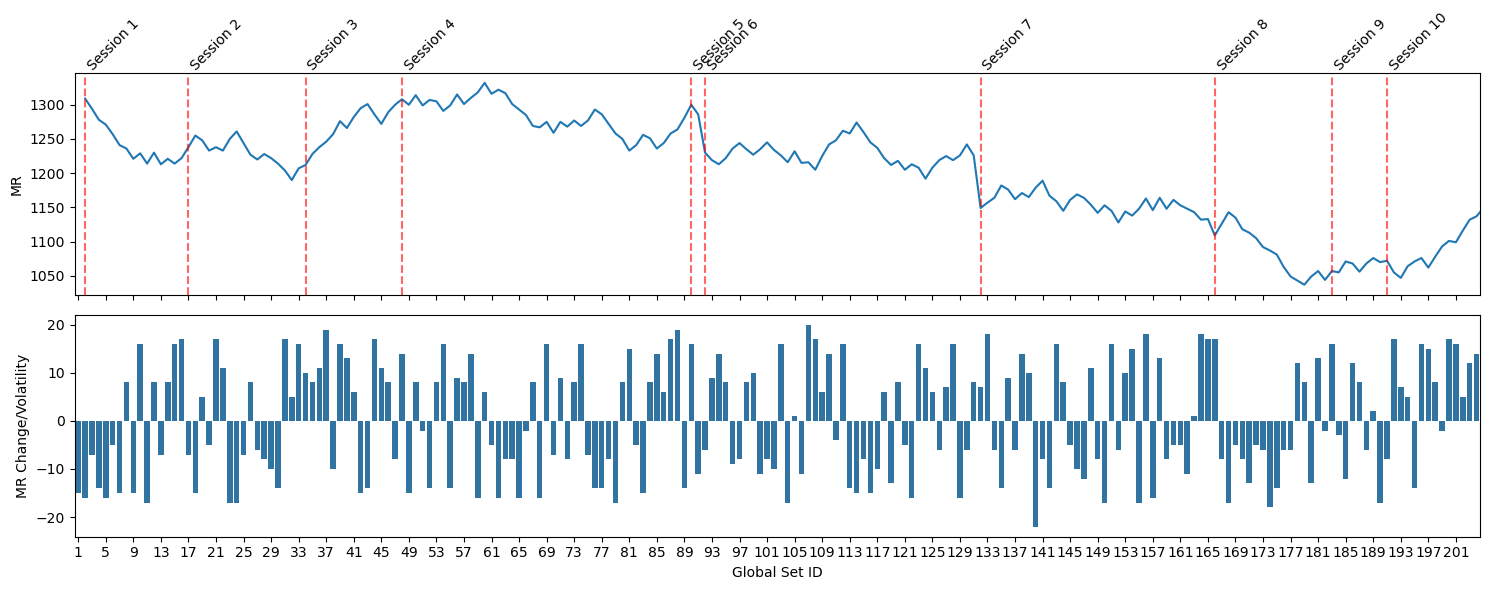

In [48]:
###creating MR visualizations
fig, axes = plt.subplots(2, 1, figsize = (15,6), sharex = True)

###MR Value
ax1 = axes[0]
sns.lineplot(data = mr_metrics, x = 'Global_Set_ID', y = 'Start_MR', ax = ax1)
ax1.set_ylabel('MR')

###mark different sessions
sessions = mr_metrics.groupby('Session ID').head(1)
for global_set in sessions['Global_Set_ID']:
    ax1.axvline(x = global_set, color = 'red', linestyle ='--', alpha = 0.6)
###label the lines
for session, global_set in enumerate(sessions['Global_Set_ID'], start = 1):
    ax1.text(x = global_set, y = ax1.get_ylim()[1], s = f'Session {session}', rotation = 45, va = 'bottom')

###MR Volatility
ax2 = axes[1]
sns.barplot(data = mr_metrics, x = 'Global_Set_ID', y = 'MR_Change')
ax2.set_xlabel('Global Set ID')
ax2.set_ylabel('MR Change/Volatility')
ax2.set_xticks(ax2.get_xticks()[::4])

plt.tight_layout()

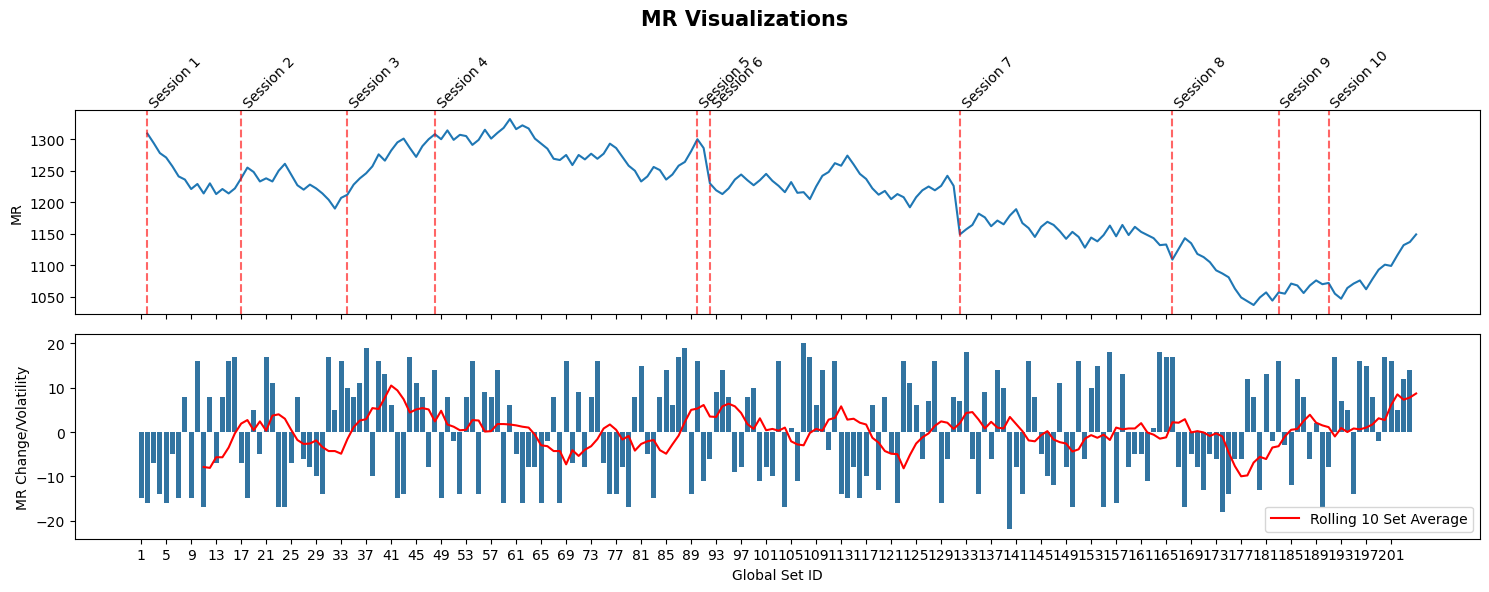

In [49]:
###volatility chart seems too noisy, create a rolling average to smooth out (say 10 set rolling average)
###create rolling10 col
mr_metrics['rolling10'] = mr_metrics['MR_Change'].rolling(window = 10).mean()
mr_metrics.tail(10)

###add it on to the MR Volatility chart and display the whole plot
fig, axes = plt.subplots(2, 1, figsize = (15,6), sharex = True)
fig.suptitle('MR Visualizations', fontsize = 15, fontweight = 'bold')

###MR Value
ax1 = axes[0]
sns.lineplot(data = mr_metrics, x = 'Global_Set_ID', y = 'Start_MR', ax = ax1)
ax1.set_ylabel('MR')

###mark different sessions
for global_set in sessions['Global_Set_ID']:
    ax1.axvline(x = global_set, color = 'red', linestyle ='--', alpha = 0.6)
###label the lines
for session, global_set in enumerate(sessions['Global_Set_ID'], start = 1):
    ax1.text(x = global_set, y = ax1.get_ylim()[1], s = f'Session {session}', rotation = 45, va = 'bottom')

###MR Volatility
ax2 = axes[1]
sns.barplot(data = mr_metrics, x = 'Global_Set_ID', y = 'MR_Change')
sns.lineplot(data = mr_metrics, x = 'Global_Set_ID', y = 'rolling10', ax = ax2, color = 'red', label = 'Rolling 10 Set Average')
ax2.set_xlabel('Global Set ID')
ax2.set_ylabel('MR Change/Volatility')
ax2.set_xticks(ax2.get_xticks()[::4])
ax2.legend(loc = 'lower right')

plt.tight_layout()

## Initial Thoughts
Throughout all 10 sessions my MR dropped from ~1300 to ~1050 and then climbed back up to ~1100.  
These recorded ranked sessions began shortly after I entered the Master Tier in Street Fighter 6.  
When first entering Master tier all new Master players are assigned a starting MR of 1500.  

This starting MR is widely regarded as not one's "True MR/True Rank" due to the 1500 MR range being in the middle of the overrall MR distribution. This starting MR acts as a baseline for new Masters players to measure their skill and find their "True MR/Rank" as they progress through more matches.

Usually, new Master players do not have enough skill or knowledge to compete with this baseline thus they are expected to fall to the 1100-1300 range once they start playing in Masters.

### Self Evaluation
These MR Visualizations express this concept quite accurately. At the beginning of Session 1 I started at 1300MR which is a tier that was still too high for my current skillset.  

After falling to the 1100-1200 (Sessions 7 and beyond) range it can be seen that my changes in MR started to become less volatile, meaning that I was starting to enter into my "True MR/Rank".

Near the end of Sessions 9 through 10 it can be seen that my MR was also starting to climb, this could represent me improving or facing opponents of equal or lesser skill level.

### Next Steps
Next we shall see what are some of the contributing factors to my losses and see if there were any changes in my play patterns between certain sessions to see if there is any improvement in my skill. 

## Statistical Analysis

Let's run some simple t-tests on certain features to see whether there is any statistical significance towards my performance.  

We will consider AA rate, Combo Drops, Burnouts, and MR difference as the key performance metrics for these tests.  

We will also look at win rate against the Opponent's Character to see where the most improvement can be made.

In [50]:
###feature encoding
###modify/create existing/new features to see what effects winning
###encoding character matchup into winrate
char_winrate = df_match.groupby('Opponent Character')['result num'].mean().round(2)
df_match['char_winrate'] = df_match['Opponent Character'].map(char_winrate)

###creating MR Difference column to see if better/lesser skilled opponents correlate to winning
df_match['MR Difference'] = df_match['Current MR'] - df_match['Opponent Rank (MR)']

df_match.head()

,Date,Session ID,Set ID,Match ID,Current MR,Opponent Rank (MR),Opponent Character,Jump ins,AA success,Combo Drops,Burnouts,Rounds Lost,Rounds Won,Result,result num,AA valid,AA rate,MR_After,char_winrate,MR Difference
0,"Feb 17, 2026",1,1,1,1309,1322,Mai,5.0,1.0,0.0,0.0,2,0,L,0,1,0.200000,1301.0,0.25,-13
1,"Feb 17, 2026",1,1,2,1301,1330,Mai,3.0,0.0,1.0,1.0,2,0,L,0,1,0.000000,1294.0,0.25,-29
2,"Feb 17, 2026",1,2,3,1294,1297,Cammy,7.0,1.0,1.0,3.0,2,1,L,0,1,0.142857,1286.0,0.53,-3
3,"Feb 17, 2026",1,2,4,1286,1305,Cammy,3.0,0.0,0.0,3.0,2,1,L,0,1,0.000000,1278.0,0.53,-19
4,"Feb 17, 2026",1,3,5,1278,1300,Ed,2.0,0.0,1.0,2.0,0,2,W,1,1,0.000000,1287.0,0.44,-22


In [51]:
###checking typical statistics for new columns
df_match[['char_winrate','MR Difference']].dropna().describe()

,char_winrate,MR Difference
count,485.000000,485.000000
mean,0.490887,-10.237113
std,0.113750,44.327755
min,0.000000,-261.000000
25%,0.470000,-32.000000
50%,0.490000,-10.000000
75%,0.560000,15.000000
max,0.670000,136.000000


In [52]:
###with MR Difference we can do an EDA on stronger and weaker opponents with regards to performance metrics
stronger = df_match[df_match['MR Difference'] <= 0]
weaker = df_match[df_match['MR Difference'] > 0]

stronger[['AA rate', 'Combo Drops', 'Burnouts', 'MR Difference', 'result num']].dropna().describe()

,AA rate,Combo Drops,Burnouts,MR Difference,result num
count,203.000000,203.000000,203.000000,203.000000,203.000000
mean,0.294695,0.517241,1.133005,-36.280788,0.497537
std,0.345516,0.655101,0.888343,37.440183,0.501230
min,0.000000,0.000000,0.000000,-261.000000,0.000000
25%,0.000000,0.000000,0.000000,-46.000000,0.000000
50%,0.200000,0.000000,1.000000,-28.000000,0.000000
75%,0.500000,1.000000,2.000000,-14.000000,1.000000
max,1.000000,3.000000,4.000000,0.000000,1.000000


In [53]:
weaker[['AA rate', 'Combo Drops', 'Burnouts', 'MR Difference', 'result num']].dropna().describe()

,AA rate,Combo Drops,Burnouts,MR Difference,result num
count,125.000000,125.000000,125.000000,125.000000,125.000000
mean,0.310197,0.552000,1.384000,28.952000,0.512000
std,0.351444,0.712288,0.998257,27.101618,0.501867
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,12.000000,0.000000
50%,0.250000,0.000000,1.000000,22.000000,1.000000
75%,0.500000,1.000000,2.000000,36.000000,1.000000
max,1.000000,2.000000,4.000000,136.000000,1.000000


## Statistical Analysis

Now that we created a stronger and weaker data set, we can see if my performance differs depending on the opponent.  

Along with this, we can see if certain metrics are statistically significant towards wins or losses.

In [54]:
###testing to see if my 'playstyle' is different depending on opponent's skill
from scipy import stats

metrics1 = ['AA rate', 'Combo Drops', 'Burnouts', 'result num']

for metric in metrics1:
    t_stat, p_value = stats.ttest_ind(
        stronger[metric].dropna(),
        weaker[metric].dropna()
    )
    print(f'{metric}: p-value:{p_value:.4f}')

AA rate: p-value:0.6953
Combo Drops: p-value:0.9645
Burnouts: p-value:0.0536
result num: p-value:0.6715


# T-Test 1: Performance against Stonger/Weaker Opponents 
These results are fairly interesting, with the exception of Burnouts (although borderline significant at p value = 0.0536), this test shows that my performance metrics (AA rates, Combo Drops) are not significantly different when facing stronger or weaker opponents.  

In other words, regardless of who I played, my measured metrics remained consistent. Whether this is positive or negative depends on in game context. For example, the inability to adapt: being unable to adjust and counter a move the opponent keeps doing, can lead to losses. Or conversely, overwhelming my opponent with such a strong offense that they can't adapt and I win the game.  

Further analysis such as character matchups can shed more light on this result.

The p value for "result num" reveals that my winrate is also not significantly different amongst stronger or weaker opponents.  

To provide further context, my winrates against stronger and weaker opponents are 49% and 51% respectively. This means that regardless of whether my opponent has higher MR than me (thus theoretically more skilled) I have an approximate 50% chance of winning the match. 

Even with this conclusion there is a small caveat. Character matchups are not all 50/50, certain characters have strict advangtages when facing other characters which can skew winrate data. For example E.Honda has a measured winrate of 64% against Dhalsim (this statistic is taken from a well known SF6 stats tracking site called Buckler). Within this project, I only used 1 character (Ryu) so a further analysis of my matchup winrate compared to Buckler's winrates can provide more insight.


In [55]:
###seeing what metrics are significantly significant amongst wins or losses
win = df_match[df_match['result num'] == 1]
loss = df_match[df_match['result num'] == 0]

metrics2 = ['AA rate', 'Combo Drops', 'Burnouts', 'MR Difference']

for metric in metrics2:
    t_stat, p_value = stats.ttest_ind(
        win[metric].dropna(),
        loss[metric].dropna()
    )
    print(f'{metric}: p-value:{p_value:.4f}')

AA rate: p-value:0.0051
Combo Drops: p-value:0.1781
Burnouts: p-value:0.0021
MR Difference: p-value:0.0562


In [56]:
win[metrics2].dropna().describe()

,AA rate,Combo Drops,Burnouts,MR Difference
count,165.000000,165.000000,165.000000,165.000000
mean,0.353800,0.575758,1.351515,-7.830303
std,0.359627,0.682101,0.902612,38.650659
min,0.000000,0.000000,0.000000,-110.000000
25%,0.000000,0.000000,1.000000,-31.000000
50%,0.333333,0.000000,1.000000,-10.000000
75%,0.500000,1.000000,2.000000,14.000000
max,1.000000,3.000000,4.000000,119.000000


In [57]:
loss[metrics2].dropna().describe()

,AA rate,Combo Drops,Burnouts,MR Difference
count,163.000000,163.000000,163.000000,163.000000
mean,0.246752,0.484663,1.104294,-15.055215
std,0.326780,0.669953,0.959768,52.947826
min,0.000000,0.000000,0.000000,-261.000000
25%,0.000000,0.000000,0.000000,-34.000000
50%,0.000000,0.000000,1.000000,-13.000000
75%,0.500000,1.000000,2.000000,14.500000
max,1.000000,3.000000,4.000000,136.000000


## T-Test 2: Win/Loss Metrics

The t-tests identified that AA rate, and Burnouts were significant features for win/loss.  

As a player, these results (with the exception of Combo Drops and MR Difference) don't surprise me, in the following sections, I will go over each metric and provide in-game context on the significance.

#### Anti-Airs and Jump ins
With regards to jump ins, when the opponent is in the air, they are conceding their ability to block. Therefore if I am able to anti air prior to them landing, it grants me free damage which then leads to a higher chance of winning. On the opposite end, if an opponent is able to land an attack on me, they are now in control and have a strong offensive advantage, which can lead to losses.  

AA rate being a significant feature in this test shows that taking advantage of opponent jump ins is a crucial part of winning matches.

#### Burnouts
The burnout mechanic is a gameplay mechanic exclusive to Street Fighter 6, without going too indepth, burnout happens when a player exhausts all their offensive resources (Drive Gauge) and is now in a state where they recover slower when they are blocking, and are also susceptible to being stunned (a state where they cannot block or move at all).  

Ideally players want to avoid being burned out as much as they can. With that being said, there is a balancing act between using your Drive Gauge to increase your damage but also not using too much to avoid burning out. 

Burnouts being a significant feature makes a lot of sense because being in a state where one is defensively compromised is a huge liability when it comes to winning.  

An improvement to towards tracking this metric could be to count burnouts that happened during the middle of the match and not ones where I burned out to secured a win. 

#### MR Difference
Street Fighter 6's MR system functions similarly to the standard Elo system. The Elo system is a mathematical model that gives the player a score that represents their skill, the higher the score the more skilled the player.  

Street Fighter 6 is a skill based 1 vs. 1 game, therefore good players are expected to accumulate points at a higher rate compared to lesser skilled players. This means when I am paired with a player with a lower score than me, the  expected outcome is a match win. When paired with a higher scored opponent, I am expected to lose. The t-test showing that MR difference was not statistically significant when predicting wins and losses was a result that was quite surprising.  

This result could be due to factors such as character matchups. For example, I would feel very confident playing against Akumas regardless of their MR, this is reflected in my personal winrate against Akuma being 60%. On the other hand, I consider matchups against Ed or Juri to be fairly difficult. It is possible that matchups familiarity can make a match more difficult than what the actual MR difference suggests. Further analysis with character matchup data could provide more context to this result.

When looking at results of t-tests 1 and 2, it paints an interesting picture. My winrate against stronger and weaker opponents are approximately 49% and 51% respectively (SD = 44 MR Difference). As a player, I expected my winrate against stronger opponents would be lower than my winrate against weaker players. 

Personally speaking, my winrate being 49% against higher rated players is quite a reassuring statistic about my gameplay. Taken in context with t-test 1, stating that performance metrics are the same regardless of opponent strength, it can be suggested that a conscious effort made to improve those metrics could positively affect winrate.

#### Combo Drops
From a player's perspective, combo drops being insignificant in predicting match outcomes was surprising. 

In a general sense, a combo is when a sequence of buttons is pressed at a certain timing to inflict damage on the opponent. If there were to be an input error during this sequence the combo would "drop" and no longer be continued, this would leave the person doing the combo vunerable to being punished. Intuitively, dropping a combo would be seen as a huge mistake which could lead to game losses.  

After reflecting on this statistic, I realized the effect a combo drop has on a match are dependant on when the drop occurred. For example, dropping a combo at the start of a match is of course detrimental, but in the beginning of the match, players are usually at full health so dropping a combo that early wouldn't directly lead to a loss.  

However, dropping a combo near the end of the match where both players are low on health has significant effects on whether games are won or lost. During my playing sessions I would remember times where I would drop the match winning combo to which my opponent would capitalize and defeat me in return. 

In the inital data gathering stage of this project, only raw combo drops were counted. An improvement on this would be to distinguish combo drops during certain times in a match such as the beginning or near the end to finish the game.



# Exploring Matchup Data

While improving one's mechanics are important aspects of winning at Street Fighter, understanding the opponent's character and their gameplan is also another key aspect of the game. Next we will look at my winrates against different characters in the game and see what matchups are worth focusing on in order to improve overall winrate.

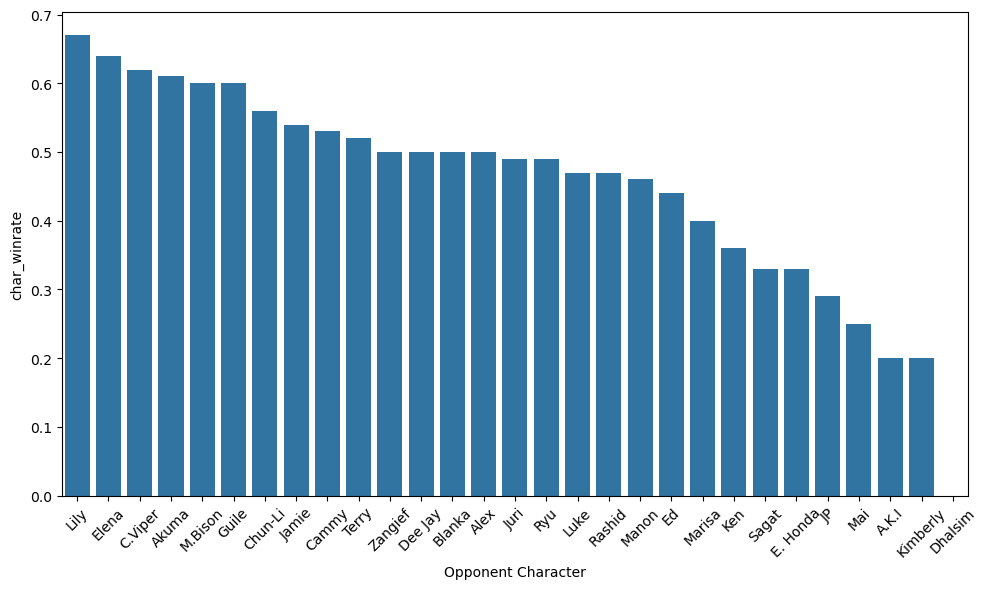

In [58]:
###visualizing matchup data
plt.figure(figsize = (10,6))
sns.barplot(df_match, x = 'Opponent Character', y = 'char_winrate', order = df_match.sort_values('char_winrate', ascending = False)['Opponent Character'])
plt.xticks(rotation = 45)
plt.tight_layout()

### Initial Thoughts

From looking at this graph, it can be seen that the Lily matchup is my most favourable one. However, the amount of times I faced each character isn't equal, there are definitely characters that I run into more frequently than others. So let's create a visual that represents winrates along with the frequency of each matchup

In [59]:
###let's create a df that has the characters, the matchup winrate and the percent of matches to visualize

df_meta = df_match.groupby('Opponent Character').agg(percent_of_matches = ('Opponent Character', lambda x: x.count()/len(df_match)*100),
                                                     Count =('Opponent Character','count'),
                                                     Winrate = ('char_winrate', 'first')).sort_values('Count',ascending = True).reset_index()

df_meta

,Opponent Character,percent_of_matches,Count,Winrate
0,Alex,0.412371,2,0.50
1,Dhalsim,0.412371,2,0.00
2,E. Honda,0.618557,3,0.33
3,Blanka,0.824742,4,0.50
4,Marisa,1.030928,5,0.40
5,M.Bison,1.030928,5,0.60
6,Kimberly,1.030928,5,0.20
7,Guile,1.030928,5,0.60
8,Sagat,1.237113,6,0.33
9,Zangief,1.649485,8,0.50


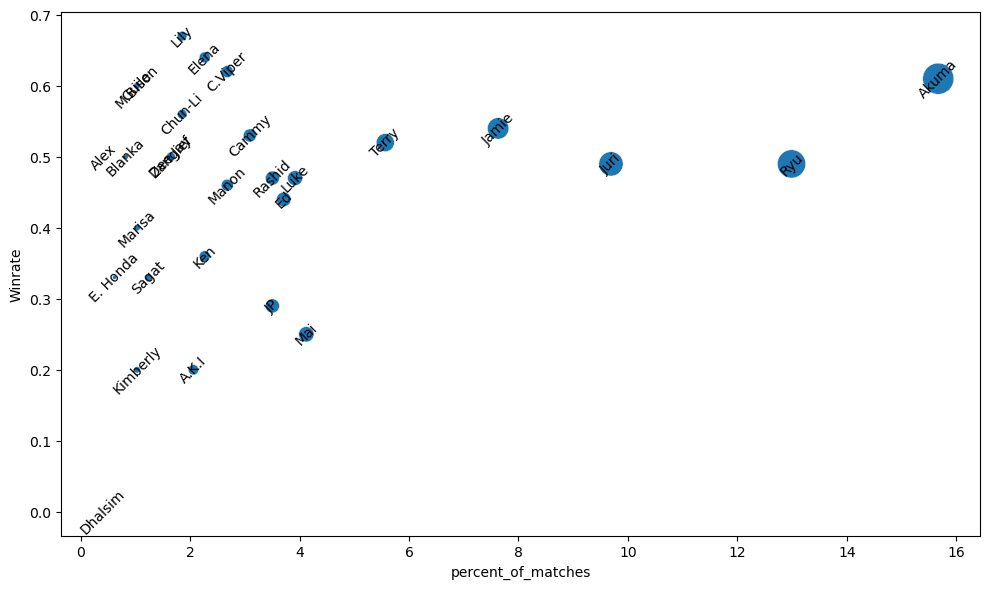

In [60]:
plt.figure(figsize=(10,6))
sns.scatterplot(df_meta, x = 'percent_of_matches', y = 'Winrate', size = 'Count', sizes = (1,500), legend = False)

for idx, row in df_meta.iterrows():
    plt.text(row['percent_of_matches'], row['Winrate'], f'{row['Opponent Character']}', ha ='center', va = 'center', rotation = 45)
plt.tight_layout()

# Interpretation

The scatterplot gives insightful context on where the majority of my wins (thus MR) is coming from. It can be seen that matchup frequency and winrate has some positive correlation to each other. This result makes sense because the more times I face a character the more experience I gain which can result in being prepared to counter gameplans or tactics the opponent may use against me. 

Character familiarity can also explain why MR Difference wasn't a strong predictor of match outcomes. From the top 5 most frequent characters we can see that the winrates are fairly equal (Akuma will be addressed further in this section). Showing that a higher rated player may still lose to me because I have gained enough experience to counter their character effectively. 

From the visualization we can see that my matchup against Akuma is extremely favourable (61% winrate) paired that with the relatively high frequency (16% of 485 of total matches), at this skill level, my knowledge against Akuma is adequate so I should focus on learning other matchups if I want to see some improvement in my MR. Intuitively if I wanted to see MR improvement, I should focus on the matchups that have high frequency and lower winrate. To analyze this further, we will focus this visual for only the top 10 frequency of matchups.

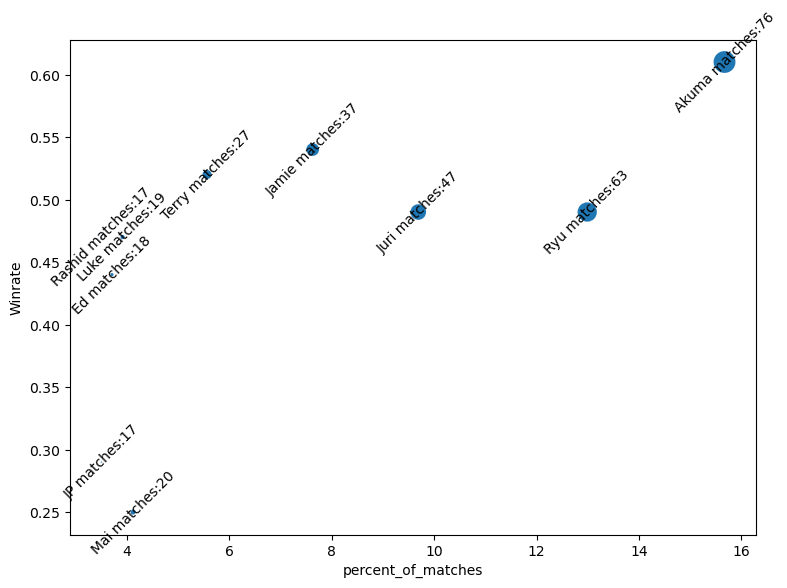

In [61]:
###lets make this visualization for my top 10 most frequent matchups
df_meta_10 = df_meta.tail(10)

plt.figure(figsize=(8,6))
sns.scatterplot(df_meta_10, x = 'percent_of_matches', y = 'Winrate', size = 'Count', sizes=(1,250), legend = False)
for idx,row in df_meta_10.iterrows():
    plt.text(row['percent_of_matches'], row['Winrate'], f'{row['Opponent Character']} matches:{row['Count']}', ha='center', va='center', rotation = 45)
plt.tight_layout()


# Interpretation

Looking at the top 10, it can be seen that there are plenty of matchups that I can still learn. The Ryu matchup in particular is my second most frequent matchup with 49% winrate. This matchup is interesting because it's Ryu vs. Ryu. Matchups where both players are playing the same character is called the "mirror match". What makes the mirror match interesting is that it is assumed that both players are fully aware of their character's tactics and gameplan so that means there won't be any situations where a player can exploit another player's lack of knowledge. That means that mechanical skill and adapting to your opponent's tendencies are the key factors to winning the mirror.

From personal experience, I do recall matches that I lost where my opponent's Ryu was far more mechanically skilled than me. I also recall the opposite case where I was far more skilled thus won the match. The winrate being 49% shows that there are still parts of my play that can be improved upon. This also tells me that I should be more aware about what my opponent is doing so I can respond with the proper counter play. Improvement in the mirror match would come from playing more games so that mechanical skill can be further practiced along with being exposed to a variety of different in-game situations.

### Other Matchups

With regards to other matchups, it can be seen that Juri is my 3rd most frequent matchup with a 49% winrate. It would be worthwhile to practice this matchup in particular because I've personally felt that this matchup was quite difficult. Ryu and Juri's playstyles are quite different so there are many situations where I feel unfamiliar in how to approach this character. Practicing common offensive and defensive scenarios against Juri can lead to an improvement in winrate.

Focusing on the Mai and JP matchups, these matchups have the lowest winrate within my top 10. The winrates are 25 and 29 percent respectively. Thinking in terms of Expected MR gain, it is extremely likely for me to lose MR when I'm matched against them. From personal experience, I've felt that these 2 characters are some of my hardest matchups. At the moment, the goal of making the winrates be +50% may be a bit too unrealistic, but pushing it from sub 30 to low to mid 40% would be more reasonable while also resulting in a big improvement in MR gain.

### Comparing Statistics

One amazing thing about this analysis is that my winrates can be compared to the "global winrates" collected from the official Street Fighter 6 site called Buckler (https://www.streetfighter.com/6/buckler/stats/dia_master). Without going too indepth, I am able to compare my personal stats with the stats collected from the website. This can give even more insight on how my performance is compared to people at my skill level and higher.

# Logistic Regression

For the final part of this analysis, we will create a logistic regression to see if the model can predict match wins based off of the metrics recorded from playing. 

In [62]:
###import all nescessary modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import sklearn.metrics as metrics

In [63]:
###drop all nan values
df_log = df_match.dropna()

In [64]:
###train test split
### we will use the same metrics2 from the previous t-test as features for the logistic regression
X = df_log[metrics2]
y = df_log['result num']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state = 42)

In [65]:
###use pipeline to scale features and to utilize the Logistic Regression model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [66]:
###create the predicted y values from the pipeline
y_pred = pipe.predict(X_test)

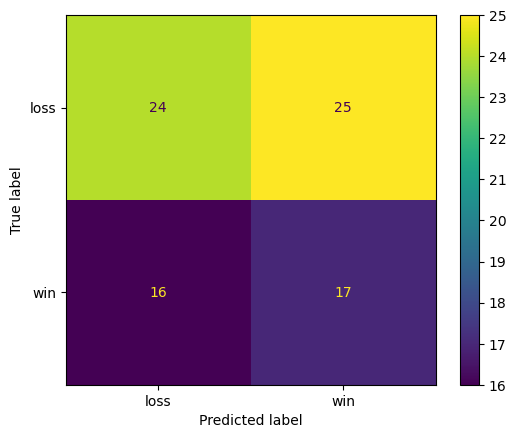

In [67]:
###create a confusion matrix to help visualize the model's predictions and to evaluate the performance of the model
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels = ['loss','win'])
disp.plot();

In [68]:
###print out evaluation metrics precision, recall, f1-score and accuracy to see how well the model predicts wins and losses
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.49      0.54        49
           1       0.40      0.52      0.45        33

    accuracy                           0.50        82
   macro avg       0.50      0.50      0.50        82
weighted avg       0.52      0.50      0.50        82



# Model Metrics

## Confusion Matrix/Classification Report

When looking at the Confusion Matrix and Classification report, it can be seen that the model is only slightly better at predicting losses then wins. The overall accuracy of the model is 0.50 which means that the model's predictive ability, to put it bluntly, is no better than a random guess. Each metric along with their results will be explained and expanded upon in the following portions of this section.

### Precision

Precision tells us the quality of the model's predictions. For the testing data there were a total of 82 matches used. From those 82 matches, the model predicted that 42 of those matches were wins, however from those 42 predicted wins it only got 17 of those predictions correct. Therefore the precision of the model is only 0.40 (17/42) or 40% . The same can be done for losses. From the 82 matches, 40 of those matches were predicted to be losses, and from those 40 matches, 24 of those were correctly predicted as losses, therefore a precision of 0.6 or 60%. 

### Recall

Recall tells us the model's ability for finding all positive samples. Looking at our test data again, there were a total of 33 won matches the model was only able to find 17 wins, resulting in a recall of 0.52 or 52%. For losses, there were a total of 49, and the model was able to find 24 leading to 0.49 or 49%.

### F1 - Score

F1-score is the harmonic mean of both Precision and Recall and is used to evaluate the model's performance wholistically. The f1-scores of losses and wins being 0.54 and 0.45 shows that the model is slightly better at predicting for losses. F1-score is usually used when the dataset contains an large imbalance of samples. In this case, the distribution of wins and losses are fairly equal so using the Accuracy metric would be sufficient enough to evaluate the model's performance. 

### Accuracy

Accuracy is the overrall rate of correct predictions. Accuracy is usually the default metric used when evaluating a model's performance specifically when the dataset's samples are fairly balanced or when incorrectly predicting an outcome does not have severe consequences. In this case, the wins and losses are farily balanced, and for the scope of this project, correctly or incorrectly predicting wins or losses is inconsequential so we will evaluate the model's performance with the Accuracy score. As previously stated in the Classification Report section, the score was shown to be 0.50 which means the model predicts correctly 50% of the time. 

## Interpretation

The Accuracy result is interesting because it shows that even when given performance metrics, this model is pretty much the same as flipping a coin. There could be many reasons why this could be the case. 

The first reason and most likely that fighting games are extremely complex. There are many more factors that go into winning a game besides anti-airing, combos, etc. A lot of these factors are also intangible and very difficult to track explicitly. There is a general consensus that being mechanically sound (anti airing jumping opponents, not dropping combos) does improve winning but what often gets missed is that fighting games are also very mental, aspects such as reading your opponent, taking advantage of their habits, limiting your own bad habits and being unpredictable are things that players should also focus on. This data project only touched upon few of the many mechanicial aspects of fighting games.

A more concrete reason for the model's result could be tied to some prior results from this analysis. T-Test 2 did show that there is a significant difference between anti-airs and burnouts for wins and losses, while the other two (combo drops and MR Difference) were shown to have no significant difference. Even though anti-airs and burnouts were shown to be significant, these 2 features alone probably don't provide a strong enough signal to the model for it to make a strong prediction. This ties back into the first point of fighting games being very complex and the determining factors for winning are very hard to predict for.

With that being said, let's still take a look at how much of an effect the features have when it comes to the model's predictions.

In [69]:
###see which coefficients contribute most to wins
coefficients = pd.DataFrame({'Feature': metrics2,
                             'Coefficients': pipe.named_steps['model'].coef_[0]})
coefficients

,Feature,Coefficients
0,AA rate,0.288546
1,Combo Drops,0.117207
2,Burnouts,0.250809
3,MR Difference,0.168891


### Feature Coefficients

Again I'm not surprised that AA rate is the feature that has the most effect when it comes to winning matches. As stated previously, games where I can consistently anti-air my opponent are the matches that I feel comfortable and are able to secure the win. 

MR Difference having a positive correlation was expected, there were instances during my sessions where I would be paired against an opponent with lower MR and I could feel the difference in our skills, in these instances I felt very confident in my gameplay and was able to win the match.

The coefficients for Combo Drops and Burnouts surprised me quite a bit. Under conventional fighting game knowledge, dropping a combo is known to be a game losing event. Similar with being in burnout, being burnt out means that you are out of offensive resources and are defensively compromised. I was expecting these 2 coefficients to be negatively correlated to winning, however, these coefficients turned out to be positive. 

There could be some reasons as to why this could be the case. The first reason is that both of these features are offensive metrics. Yes it is bad to drop a combo and it is an unfavourable situation if you are in burnout. However, both these situations involve pressuring your opponent and in Street Fighter 6, if you are in that position it is generally favourable. Therefore, it can be suggested that these features can also indicate some sort of metric to measure offensive ability.

The effect of combo drops in a match are very time dependent and contextual. As stated earlier in this analysis, dropping a combo at the beginning of the round is indeed bad but the player will still probably have enough health to play on for the rest of the match. On the other hand, dropping the combo near end of the match can greatly affect the result because the opposing player can take advantage of the mistake and steal the win. In the data recording stage, only raw combo drop counts were recorded, indicating when the combo was dropped and if a combo drop directly resulted in a loss are ways to improve this metric.

In Street Fighter 6 there is a resource called Drive Meter, this meter is used to extend combos, and increase damage, when the player uses up all their Drive Meter they enter burnout. The Drive meter is the one of the most important resources in Street Fighter 6 and the player has to balance using enough to win the game while also not using too much to avoid burnout. Similar to combos drops, burning out means that the player was in an offensive position. However, when the offensive push is over, the disadvantage of burnout takes place. An improvement to this metric would be to count how many burnouts lead to a game winning combo or which burnouts lead to being stunned. 

# Final Thoughts, Conclusion, Limitations and Personal Reflection

Firstly, I would like to say thank you for taking the time in reading this small project of mine and I appreciate any feedback that will help me grow in this data analyst journey. 

## Scope and Summary

To summarize, the scope of this project was to record and analyze roughly 400+ ranked matches of my gameplay and to see which metrics correlated to winning. Metrics such as anti-airing, combo drops, burnouts and MR difference were the main features chosen as these metrics are simple, well known within the Street Fighter Community, and easy to understand/measure.

The analysis consisted of the following:

1. Visualization of MR and MR Change over the course of 10 gaming sessions.
2. Two T-tests, first one testing if metrics and winrate had any significant difference when facing stronger or weaker opponents. Second one testing which metrics were statistically significant in matches that were wins/losses.
3. Visualization of Character Matchup data.
4. Logistic Regression model and classification report to see if the metrics can provide a strong predictor for winning.
5. Interpretation of Feature Coefficients to see which coefficients had the biggest influence on the model.

A summary of the results would be the following:

1. My initial MR dropped drastically as I was still in a rank far above my skill level, but after a few sessions I found my "true rank" and MR started to stabilize.
2. T-test 1: Metrics and winrate were not significantly different when compared to stronger or weaker opponents,
   T-test 2: Anti airs, and burnouts were statistically significant in matches that were won compared to lost while combo drops and MR difference were not.
3. Akuma was a large percentage of the matches I played along with the most successful. It would be worthwhile to focus on Ed, Juri, Mai and JP matchups if I want to see an improvement of my MR.
4. The model's predictive power ended up being 50% which is no better than a random guess. Reasons for this could be due to the overall nature of Fighting games being very complex along with how the data/metrics were recorded during the data collection phase.
5. As expected Anti-airs had the strongest influence in predicting wins, conversely, combo drops and burnouts had some positive influence even though these metrics are generally considered as "negative". Again, this result may be due to how the metrics were measured during the data collection phase.

## Limitations

As stated in prior sections, the most obvious limitation was the recording of data during the collection phase. All the data was recorded and inputted manually, that means I watched every single match and recorded the metrics as I went. The data collection process also occured over the course of a new game patch which led to the loss of 100 in game matches. This portion took a lot longer than I expected, and it gave me new perspective of how time consuming the data collection of real projects could be. 

As diligent as I was, there were definitely times where the data was inputted incorrectly and had to be cleaned during the data cleaning process. This part of the analysis alone really showed to me how important the cleaning step is. Despite this being my own data and my own recordings I still made inputting errors and it made me realize how dirty real life data could actually be!

Another limitation was time contextual features such as combo drops and burnouts. Due to these features being context dependant a lot of the nuance of these metrics were lost when just recording their raw counts. For future analyses, I will definitely incorporate some way to differentiate when these instances occurred. 

## Personal Reflection

When I took up this project I was extremely excited, especially because it involved applying the skills I learned from my online courses with my hobby of playing Street Fighter 6. It was really cool to use my prior game knowledge to create a hypothesis/assumption and have the results from the analysis prove/disprove them. This project really helped get a deeper appreciation for this line of work and gave me even more inspiration to grow my skills even more.

I would be lying if I said I didn't use any form of genAI to help write this project. I did use Claude to help me with looking up syntax for certain lines of code (for some reason I can NEVER remember how to format visualizations with seaborn and matplotlib), to spell check, and to help articulate my thoughts better for the write ups. However! Nothing was copy and pasted, everything was typed by my own hands and all my conclusions/interpretations of these results are from my own thoughts, so if anything is incorrect, that's all on me and please tell me where I can correct it :).

That being said, thank you again for taking the time to read this project and if you happen to have ANY leads on some entry level positions in the Data Analyst field (especially in Toronto, Canada) I would gladly appreciate it!

Ryan.